## Libraries Used

In [20]:
import pandas as pd
import numpy as np
#We use this when files are inside folder
import os

In [21]:
# Folder path
path = r"C:\Users\HP\Desktop\Data analanalyst folder\E-Commerce Sales Analysis\Raw Data"


### Load Dataset

In [22]:
orders = pd.read_csv(os.path.join(path,"olist_orders_dataset.csv"))
order_items = pd.read_csv(os.path.join(path,"olist_order_items_dataset.csv"))
products = pd.read_csv(os.path.join(path,"olist_products_dataset.csv"))
customers = pd.read_csv(os.path.join(path,"olist_customers_dataset.csv"))
reviews = pd.read_csv(os.path.join(path,"olist_order_reviews_dataset.csv"))
category_translation = pd.read_csv(os.path.join(path,"product_category_name_translation.csv"))

print ("All the Files Loaded")

All the Files Loaded


### Check Data

In [23]:
print("orders:",orders.shape)
print("order_items:",order_items.shape)
print("products:",products.shape)
print("customers:",customers.shape)
print("reviews:",reviews.shape)
print("category_translation:",category_translation.shape)

orders: (99441, 8)
order_items: (112650, 7)
products: (32951, 9)
customers: (99441, 5)
reviews: (99224, 7)
category_translation: (71, 2)


### Data cleaning for orders dataset

In [24]:
## Checking for NULL values
orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [25]:
## Checking frequency
orders['order_status'].value_counts(normalize=True) * 100

order_status
delivered      97.020344
shipped         1.113223
canceled        0.628513
unavailable     0.612423
invoiced        0.315765
processing      0.302692
created         0.005028
approved        0.002011
Name: proportion, dtype: float64

In [26]:
# Checking the duplicates present in orders dataset
orders.duplicated().sum()

np.int64(0)

In [27]:
# Fixing Data types for orders dataset

date_columns = ["order_purchase_timestamp",
                "order_approved_at",
                "order_delivered_carrier_date",
                "order_delivered_customer_date",
                "order_estimated_delivery_date"]
for col in date_columns: orders[col] = pd.to_datetime( orders[col], errors = "coerce")

print("date_columns converted")

date_columns converted


In [28]:
# Created year and month columns from the orders dataset for monthly and yearly trend analysis.

orders['order_year'] = orders['order_purchase_timestamp'].dt.year
orders['order_month'] = orders['order_purchase_timestamp'].dt.strftime('%Y-%m')

In [29]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 10 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  str           
 1   customer_id                    99441 non-null  str           
 2   order_status                   99441 non-null  str           
 3   order_purchase_timestamp       99441 non-null  datetime64[us]
 4   order_approved_at              99281 non-null  datetime64[us]
 5   order_delivered_carrier_date   97658 non-null  datetime64[us]
 6   order_delivered_customer_date  96476 non-null  datetime64[us]
 7   order_estimated_delivery_date  99441 non-null  datetime64[us]
 8   order_year                     99441 non-null  int32         
 9   order_month                    99441 non-null  str           
dtypes: datetime64[us](5), int32(1), str(4)
memory usage: 7.2 MB


In [30]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_year,order_month
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017,2017-10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018,2018-07
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018,2018-08
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017,2017-11
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2018,2018-02


### Data cleaning for products dataset

In [31]:
products.info()

<class 'pandas.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  str    
 1   product_category_name       32341 non-null  str    
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), str(2)
memory usage: 2.3 MB


In [32]:
## Checking sum of duplicates
products.duplicated().sum()

np.int64(0)

In [33]:
## Finding sum of NULL values
products.isnull().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

In [34]:
## Filling NULL values with N/A
products['product_category_name'] = products['product_category_name'].fillna('N/A')

In [35]:
# Selecting column and removed the unecessary columns
products = products[['product_id', 'product_category_name']]

In [36]:
products.head()

,product_id,product_category_name
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria
1,3aa071139cb16b67ca9e5dea641aaa2f,artes
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer
3,cef67bcfe19066a932b7673e239eb23d,bebes
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas


### Data cleaning for order_items dataset

In [37]:
print(order_items.dtypes)

order_id                   str
order_item_id            int64
product_id                 str
seller_id                  str
shipping_limit_date        str
price                  float64
freight_value          float64
dtype: object


In [38]:
# Fixing data types for order_items table
order_items["shipping_limit_date"]= pd.to_datetime(order_items["shipping_limit_date"],errors = "coerce")
order_items.info()

<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   order_id             112650 non-null  str           
 1   order_item_id        112650 non-null  int64         
 2   product_id           112650 non-null  str           
 3   seller_id            112650 non-null  str           
 4   shipping_limit_date  112650 non-null  datetime64[us]
 5   price                112650 non-null  float64       
 6   freight_value        112650 non-null  float64       
dtypes: datetime64[us](1), float64(2), int64(1), str(3)
memory usage: 6.0 MB


In [39]:
# Finding revenue 
order_items["revenue"] = order_items["price"]+order_items["freight_value"]
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,revenue
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,72.19
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,259.83
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,216.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,218.04


### Data cleaning for customers dataset

In [40]:
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  int64
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes: int64(1), str(4)
memory usage: 3.8 MB


In [41]:
## Finding sum of NULL values
customers.isnull().sum()

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

In [42]:
## Checking sum of duplicates
customers.duplicated().sum()

np.int64(0)

In [43]:
# Selecting useful columns and removing unnecessary columns
customers = customers[['customer_id', 'customer_city', 'customer_state']]

In [44]:
customers.head()

,customer_id,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,campinas,SP


### Data cleaning for reviews dataset

In [45]:
reviews.info()

<class 'pandas.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   review_id                99224 non-null  str  
 1   order_id                 99224 non-null  str  
 2   review_score             99224 non-null  int64
 3   review_comment_title     11568 non-null  str  
 4   review_comment_message   40977 non-null  str  
 5   review_creation_date     99224 non-null  str  
 6   review_answer_timestamp  99224 non-null  str  
dtypes: int64(1), str(6)
memory usage: 5.3 MB


In [46]:
## Finding sum of NULL values
reviews.isnull().sum()

review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

In [47]:
## SELECTING COLUMNS AND REMOVING UNECESSARY ONES
reviews = reviews[['review_id','order_id', 'review_score']]

In [48]:
reviews.head()

,review_id,order_id,review_score
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5


In [49]:
# Convert review_score to numeric and remove wrong values like date
reviews['review_score'] = pd.to_numeric(reviews['review_score'], errors='coerce')

# Keep only valid review scores 1 to 5
reviews = reviews[reviews['review_score'].between(1, 5)]

# Convert review_score into integer
reviews['review_score'] = reviews['review_score'].astype(int)

reviews['review_score'].value_counts().sort_index()
# Cleaned review_score column by removing invalid values and keeping only valid ratings from 1 to 5.

review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

### Data cleaning for category_translation dataset

In [50]:
category_translation.info()

<class 'pandas.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   product_category_name          71 non-null     str  
 1   product_category_name_english  71 non-null     str  
dtypes: str(2)
memory usage: 1.2 KB


In [51]:
# Renaming column in category_translation file
category_translation=category_translation.rename(columns = {'ï»¿product_category_name':'product_category_name'})
category_translation.columns

Index(['product_category_name', 'product_category_name_english'], dtype='str')

In [52]:
## Checking sum of duplicates
category_translation.duplicated().sum()

np.int64(0)

In [53]:
category_translation.info()

<class 'pandas.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   product_category_name          71 non-null     str  
 1   product_category_name_english  71 non-null     str  
dtypes: str(2)
memory usage: 1.2 KB


### Merging all cleaned dataset into final one.

In [54]:
# Merge orders and order_items
df = orders.merge(order_items,on="order_id", how="inner")
df = df.merge(products,on="product_id", how="left")
df = df.merge(customers,on="customer_id", how="left")
df = df.merge(reviews[["order_id", "review_score"]],on="order_id", how="left")
df = df.merge(category_translation,on="product_category_name", how="left")

print("Merged file data shape:",df.shape)
df.head()


Merged file data shape: (113314, 22)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_year,order_month,...,seller_id,shipping_limit_date,price,freight_value,revenue,product_category_name,customer_city,customer_state,review_score,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017,2017-10,...,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,38.71,utilidades_domesticas,sao paulo,SP,4.0,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018,2018-07,...,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,141.46,perfumaria,barreiras,BA,4.0,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018,2018-08,...,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,179.12,automotivo,vianopolis,GO,5.0,auto
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017,2017-11,...,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,72.20,pet_shop,sao goncalo do amarante,RN,5.0,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2018,2018-02,...,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,28.62,papelaria,santo andre,SP,5.0,stationery


In [55]:
df.shape

(113314, 22)

In [56]:
## Removing unecessary column
df.drop(columns=['product_category_name'], inplace=True)

In [57]:
df.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'order_year', 'order_month', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value', 'revenue',
       'customer_city', 'customer_state', 'review_score',
       'product_category_name_english'],
      dtype='str')

In [58]:
df['delivery_days'] = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.days

In [59]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_year,order_month,...,seller_id,shipping_limit_date,price,freight_value,revenue,customer_city,customer_state,review_score,product_category_name_english,delivery_days
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017,2017-10,...,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,38.71,sao paulo,SP,4.0,housewares,8.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018,2018-07,...,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,141.46,barreiras,BA,4.0,perfumery,13.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018,2018-08,...,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,179.12,vianopolis,GO,5.0,auto,9.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017,2017-11,...,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,72.20,sao goncalo do amarante,RN,5.0,pet_shop,13.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2018,2018-02,...,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,28.62,santo andre,SP,5.0,stationery,2.0


In [60]:
## Sorting columns in ascending order
df.isnull().sum().sort_values(ascending=False)

delivery_days                    2475
order_delivered_customer_date    2475
product_category_name_english    1636
order_delivered_carrier_date     1203
review_score                      942
order_approved_at                  15
order_status                        0
order_purchase_timestamp            0
order_id                            0
customer_id                         0
order_item_id                       0
order_estimated_delivery_date       0
order_year                          0
order_month                         0
shipping_limit_date                 0
seller_id                           0
product_id                          0
price                               0
customer_city                       0
revenue                             0
freight_value                       0
customer_state                      0
dtype: int64

In [61]:
## Filling NULL values with unknown
df['product_category_name_english'] = (df['product_category_name_english'].fillna('Unknown'))

In [62]:
## Rows with missing values are deleted
df = df[df['revenue'].notna()]

In [63]:
df.isnull().sum().sort_values(ascending=False)

delivery_days                    2475
order_delivered_customer_date    2475
order_delivered_carrier_date     1203
review_score                      942
order_approved_at                  15
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_id                            0
order_estimated_delivery_date       0
order_item_id                       0
product_id                          0
order_year                          0
order_month                         0
shipping_limit_date                 0
seller_id                           0
price                               0
freight_value                       0
customer_city                       0
revenue                             0
customer_state                      0
product_category_name_english       0
dtype: int64

In [64]:
## Exporting the final dataset
output_path =  r"."
os.makedirs(output_path ,exist_ok=True)
df.to_csv(os.path.join(output_path,"olist_cleaned.csv"),index=False)
print("File Cleaned")

File Cleaned


### OLIST FILE IS CLEANED
#### This final dataset contains useful columns required for analysis, such as order details, customer location, product category, price, freight value, and revenue.

In [65]:
df

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_year,order_month,...,seller_id,shipping_limit_date,price,freight_value,revenue,customer_city,customer_state,review_score,product_category_name_english,delivery_days
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017,2017-10,...,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,38.71,sao paulo,SP,4.0,housewares,8.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018,2018-07,...,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,141.46,barreiras,BA,4.0,perfumery,13.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018,2018-08,...,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,179.12,vianopolis,GO,5.0,auto,9.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017,2017-11,...,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,72.20,sao goncalo do amarante,RN,5.0,pet_shop,13.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2018,2018-02,...,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,28.62,santo andre,SP,5.0,stationery,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113309,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02,2018,2018-02,...,1f9ab4708f3056ede07124aad39a2554,2018-02-12 13:10:37,174.90,20.10,195.00,praia grande,SP,4.0,baby,22.0
113310,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27,2017,2017-08,...,d50d79cb34e38265a8649c383dcffd48,2017-09-05 15:04:16,205.99,65.02,271.01,nova vicosa,BA,5.0,home_appliances_2,24.0
113311,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,2018,2018-01,...,a1043bafd471dff536d0c462352beb48,2018-01-12 21:36:21,179.99,40.59,220.58,japuiba,RJ,2.0,computers_accessories,17.0
113312,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,2018,2018-01,...,a1043bafd471dff536d0c462352beb48,2018-01-12 21:36:21,179.99,40.59,220.58,japuiba,RJ,2.0,computers_accessories,17.0


In [ ]:
df.columns()

<Axes: >

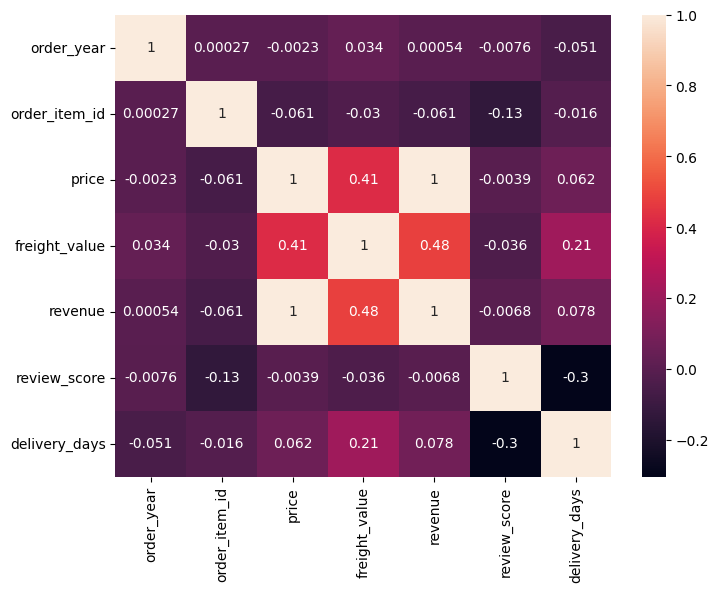

In [116]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),annot=True)
